# Overview

We will use a `mnist` dataset for training and testing a neural network. The first layer will have $784$ nodes, second and third layer will have $20$, and the last output layer will have $10$.

## Reference

https://medium.com/@waadlingaadil/learn-to-build-a-neural-network-from-scratch-yes-really-cac4ca457efc

## Note

**We need to write more comments**

# Header

In [115]:
import numpy as np # heheheha
import matplotlib.pyplot as plt # for plotting
import pandas as pd # reading csv files

# MNIST CSV Processing

In [116]:
def read_mnist_csv(filepath):
    df = pd.read_csv(filepath)
    
    y = df.iloc[:, 0].values
    Y = np.zeros((y.shape[0], 10))
    for i in range(y.shape[0]):
        Y[i, y[i]] = 1.0
    X = df.iloc[:, 1:].values
    
    X = X / 255.0
    
    return X, y

train_data = read_mnist_csv('mnist_train.csv')
test_data = read_mnist_csv('mnist_test.csv')

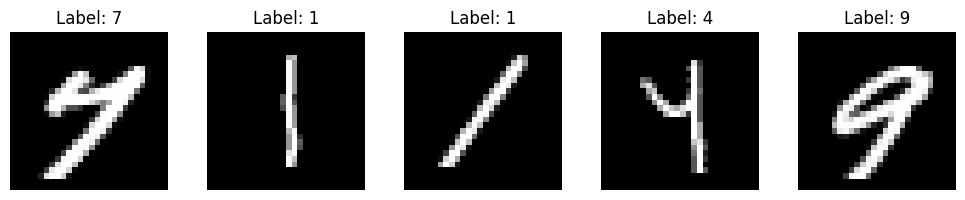

In [117]:
def mnist_visualize(data, index=0, num_images=5, figsize=(10, 2)):
    X, y = data
    fig, axes = plt.subplots(1, num_images, figsize=figsize)
    
    for i in range(num_images):
        if num_images == 1:
            ax = axes
        else:
            ax = axes[i]
            
        img_idx = index + i
        if img_idx < len(X):
            img = X[img_idx].reshape(28, 28)
            
            ax.imshow(img, cmap='gray')
            ax.set_title(f"Label: {y[img_idx]}")
            ax.axis('off')
    
    plt.tight_layout()
    plt.show()

mnist_visualize(train_data, index=1000, num_images=5, figsize=(10, 2))

In [118]:
def initialize_parameters():
    np.random.seed(42)

    input_size = 784  
    hidden_size1 = 20
    hidden_size2 = 20
    output_size = 10

    W1 = np.random.rand(input_size, hidden_size1) * 0.01
    b1 = np.zeros((1, hidden_size1))
    
    W2 = np.random.rand(hidden_size1, hidden_size2) * 0.01
    b2 = np.zeros((1, hidden_size2))
    
    W3 = np.random.rand(hidden_size2, output_size) * 0.01
    b3 = np.zeros((1, output_size))
    
    parameters = {"w1": W1, "b1": b1,
                  "w2": W2, "b2": b2,
                  "w3": W3, "b3": b3}
    
    return parameters

# Normalize Output

In [119]:
def normalize_output(z):
    out = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(out)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# Sigma Function - PReLU

In [120]:
def PReLU(z):
    return np.where(z > 0, z, 0.001 * z)

# Neural Network

In [121]:
Xs, ys = train_data
print(Xs.shape, ys.shape)

(59999, 784) (59999,)


In [122]:
def forward_propagation(wh, parameters):  
    mnist_visualize(train_data, index=wh, num_images=1, figsize=(10, 2))  
    X = Xs[wh:wh+1]
    y = ys[wh:wh+1]
    w1, b1 = parameters["w1"], parameters["b1"]
    w2, b2 = parameters["w2"], parameters["b2"]
    w3, b3 = parameters["w3"], parameters["b3"]

    z1 = X @ w1 + b1
    a1 = PReLU(z1)

    z2 = a1 @ w2 + b2
    a2 = PReLU(z2)

    z3 = a2 @ w3 + b3
    a3 = PReLU(z3)
    
    output = normalize_output(a3)
    
    print("it is:", np.argmax(output, axis=1))
    return output

# forward_propagation(0, initialize_parameters())

In [123]:
def backward_propagation(X, y, parameters):
    w1, b1 = parameters["w1"], parameters["b1"]
    w2, b2 = parameters["w2"], parameters["b2"]
    w3, b3 = parameters["w3"], parameters["b3"]

    m = X.shape[0]
    
    z1 = X @ w1 + b1
    a1 = PReLU(z1)

    z2 = a1 @ w2 + b2
    a2 = PReLU(z2)

    z3 = a2 @ w3 + b3
    a3 = PReLU(z3)
    
    output = normalize_output(a3)
    
    delta3 = output - y
    dw3 = np.dot(a2.T, delta3) / m
    db3 = np.sum(delta3, axis=0, keepdims=True) / m
    
    delta2 = np.dot(delta3, w3.T) * (a2 > 0)
    dw2 = np.dot(a1.T, delta2) / m
    db2 = np.sum(delta2, axis=0, keepdims=True) / m
    
    delta1 = np.dot(delta2, w2.T) * (a1 > 0)
    dw1 = np.dot(X.T, delta1) / m
    db1 = np.sum(delta1, axis=0, keepdims=True) / m
    
    grads = {"dw1": dw1, "db1": db1,
             "dw2": dw2, "db2": db2,
             "dw3": dw3, "db3": db3}
    
    return grads

def cost(y, y_hat): 
    """
    Implements the L2 Cost Function

    Args:
        y (numpy.ndarray): intended labels
        y_hat (numpy.ndarray): network labels

    Returns:
        loss (float): L2 cost function value
    """
    loss = np.mean(np.sum((y - y_hat) ** 2, axis=1)) / 2.0
    return loss


In [ ]:
def train(X, y, parameters, learning_rate=0.01, num_iterations=1000):
    costs = []
    
    for i in range(num_iterations):
        output = forward_propagation(X, y, parameters)
        cost_value = cost(y, output)
        costs.append(cost_value)

        grads = backward_propagation(X, y, parameters)

        parameters["w1"] -= learning_rate * grads["dw1"]
        parameters["b1"] -= learning_rate * grads["db1"]
        parameters["w2"] -= learning_rate * grads["dw2"]
        parameters["b2"] -= learning_rate * grads["db2"]
        parameters["w3"] -= learning_rate * grads["dw3"]
        parameters["b3"] -= learning_rate * grads["db3"]

        if i % 100 == 0:
            print(f"Cost after iteration {i}: {cost_value}")

    return parameters, costs

params, cost = train(Xs, ys, initialize_parameters(), learning_rate=0.01, num_iterations=1000)

forward_propagation(Xs[0], ys[0], params)

TypeError: forward_propagation() takes 2 positional arguments but 3 were given